**1. 모든 음식점**

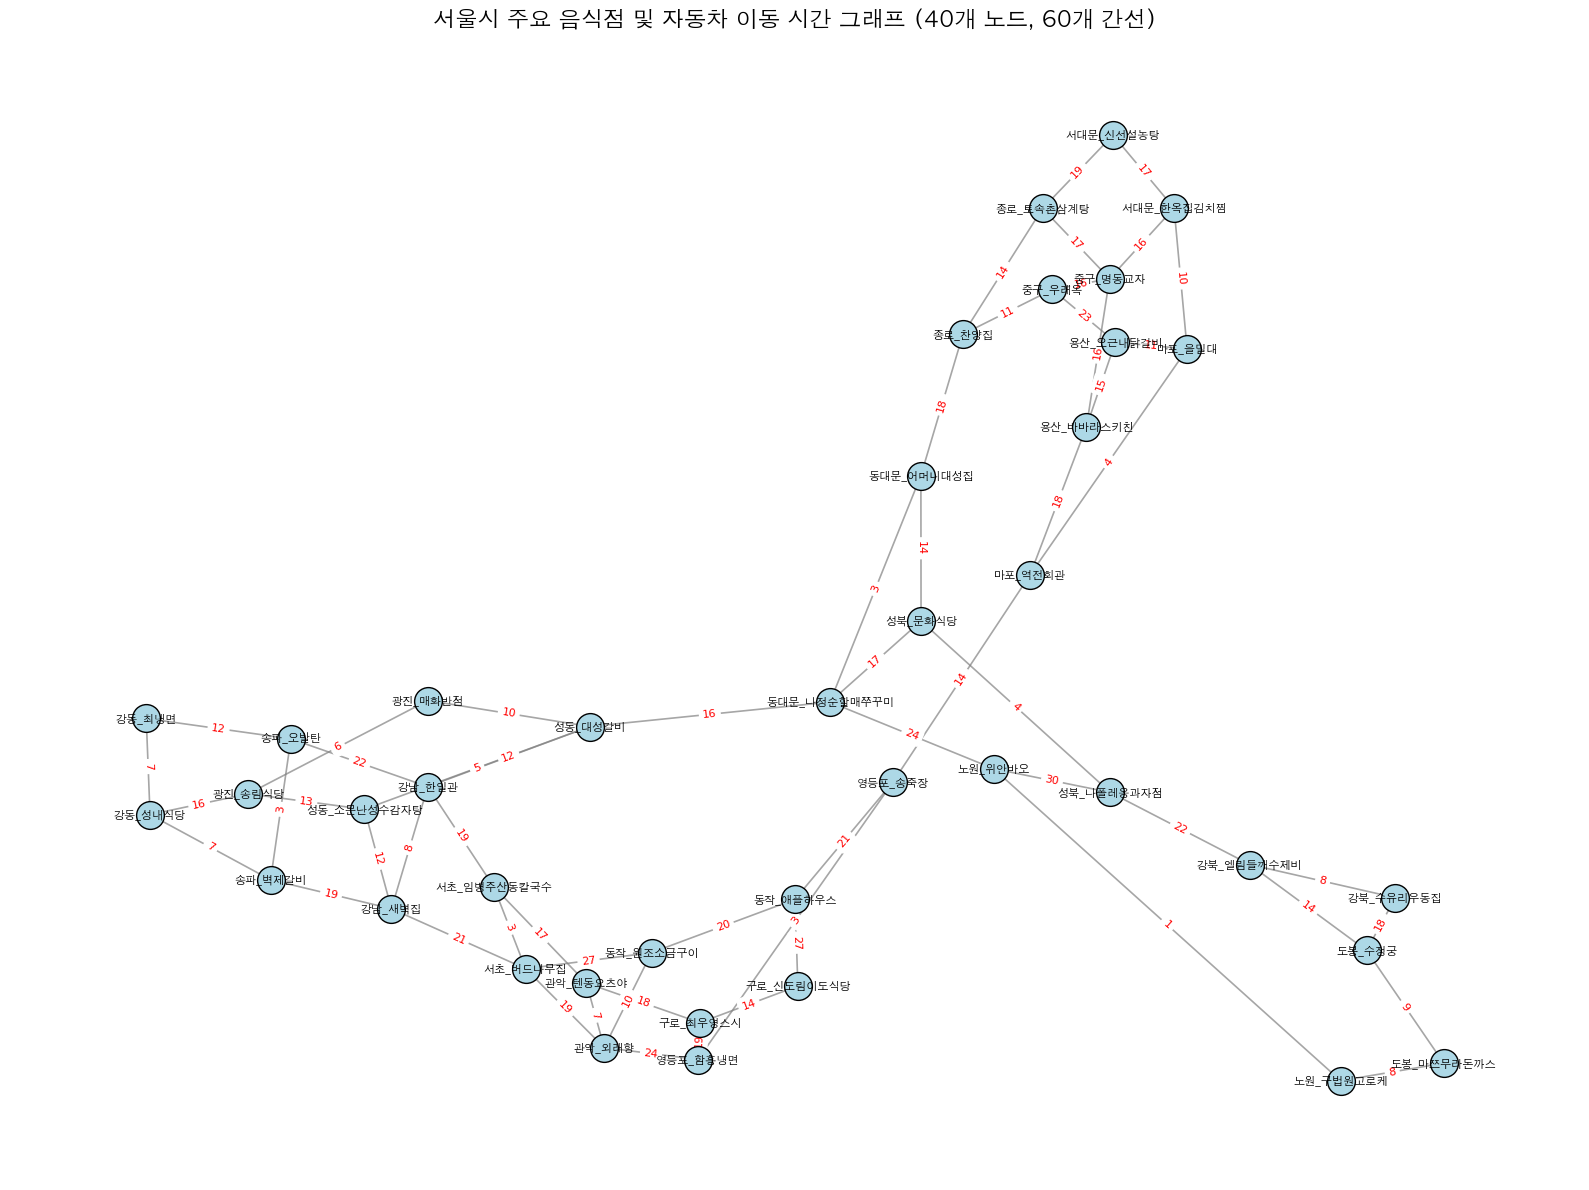

In [1]:
import matplotlib.pyplot as plt
import networkx as nx

# 1. 40개 실제 음식점 노드 정의
restaurants = [
    "강남_새벽집", "강남_한일관", "서초_버드나무집", "서초_임병주산동칼국수",
    "송파_벽제갈비", "송파_오발탄", "강동_최냉면", "강동_성내식당",
    "광진_송림식당", "광진_매화반점", "성동_대성갈비", "성동_소문난성수감자탕",
    "동작_원조소금구이", "관악_외래향", "관악_텐동요츠야", "용산_오근내닭갈비",
    "용산_바바라스키친", "중구_우래옥", "중구_명동교자", "종로_토속촌삼계탕",
    "종로_찬양집", "동대문_어머니대성집", "동대문_나정순할매쭈꾸미", "성북_문화식당",
    "성북_나폴레옹과자점", "강북_엘림들깨수제비", "강북_수유리우동집", "도봉_수정궁",
    "도봉_마쯔무라돈까스", "노원_구법원고로케", "노원_위안바오", "마포_역전회관",
    "마포_을밀대", "서대문_한옥집김치찜", "서대문_신선설농탕", "영등포_송죽장",
    "영등포_함흥냉면", "구로_최우영스시", "구로_신도림이도식당", "동작_애플하우스"
]

# 2. 직접 조사하신 60개 간선(이동 시간) 데이터 입력 [간선은 방향성이 없음]
edge_list = [
    # 강남, 서초, 송파, 강동, 성동, 광진 권역
    ("강남_새벽집", "강남_한일관", 8),
    ("강남_새벽집", "서초_버드나무집", 21),
    ("강남_한일관", "서초_임병주산동칼국수", 19),
    ("서초_버드나무집", "서초_임병주산동칼국수", 3),
    ("강남_새벽집", "송파_벽제갈비", 19),
    ("강남_한일관", "송파_오발탄", 22),
    ("송파_벽제갈비", "송파_오발탄", 3),
    ("송파_오발탄", "강동_최냉면", 12),
    ("강동_최냉면", "강동_성내식당", 7),
    ("강동_성내식당", "광진_송림식당", 16),
    ("광진_송림식당", "광진_매화반점", 6),
    ("광진_매화반점", "성동_대성갈비", 10),
    ("성동_대성갈비", "성동_소문난성수감자탕", 5),
    ("성동_소문난성수감자탕", "강남_새벽집", 12),
    ("서초_버드나무집", "동작_원조소금구이", 27),
    ("송파_벽제갈비", "강동_성내식당", 7),
    ("광진_송림식당", "성동_소문난성수감자탕", 13),
    ("강남_한일관", "성동_대성갈비", 12),
    ("서초_임병주산동칼국수", "관악_텐동요츠야", 17),
    ("동작_원조소금구이", "관악_외래향", 10),
    # 용산, 중구, 종로, 동대문, 성북, 강북, 도봉, 노원 권역
    ("용산_오근내닭갈비", "용산_바바라스키친", 15),
    ("용산_오근내닭갈비", "중구_우래옥", 23),
    ("중구_명동교자", "중구_우래옥", 16),
    ("중구_명동교자", "종로_토속촌삼계탕", 17),
    ("종로_토속촌삼계탕", "종로_찬양집", 14),
    ("종로_찬양집", "동대문_어머니대성집", 18),
    ("동대문_어머니대성집", "동대문_나정순할매쭈꾸미", 3),
    ("동대문_나정순할매쭈꾸미", "성북_문화식당", 17),
    ("성북_나폴레옹과자점", "성북_문화식당", 4),
    ("성북_나폴레옹과자점", "강북_엘림들깨수제비", 22),
    ("강북_엘림들깨수제비", "강북_수유리우동집", 8),
    ("강북_수유리우동집", "도봉_수정궁", 18),
    ("도봉_수정궁", "도봉_마쯔무라돈까스", 9),
    ("도봉_마쯔무라돈까스", "노원_구법원고로케", 8),
    ("노원_위안바오", "노원_구법원고로케", 1),
    ("동대문_어머니대성집", "성북_문화식당", 14),
    ("중구_우래옥", "종로_찬양집", 11),
    ("용산_바바라스키친", "중구_명동교자", 16),
    ("성북_나폴레옹과자점", "노원_위안바오", 30),
    ("강북_엘림들깨수제비", "도봉_수정궁", 14),
    # 마포, 서대문, 영등포, 구로, 동작, 관악 및 권역 연결
    ("마포_역전회관", "마포_을밀대", 4),
    ("마포_을밀대", "서대문_한옥집김치찜", 10),
    ("서대문_한옥집김치찜", "서대문_신선설농탕", 17),
    ("서대문_신선설농탕", "종로_토속촌삼계탕", 19),
    ("마포_역전회관", "영등포_송죽장", 14),
    ("영등포_송죽장", "영등포_함흥냉면", 3),
    ("영등포_함흥냉면", "구로_최우영스시", 19),
    ("구로_최우영스시", "구로_신도림이도식당", 14),
    ("구로_신도림이도식당", "동작_애플하우스", 27),
    ("동작_원조소금구이", "동작_애플하우스", 20),
    ("관악_텐동요츠야", "관악_외래향", 7),
    ("관악_텐동요츠야", "구로_최우영스시", 18),
    ("영등포_송죽장", "동작_애플하우스", 21),
    ("마포_을밀대", "용산_오근내닭갈비", 11),
    ("서대문_한옥집김치찜", "중구_명동교자", 16),
    ("영등포_함흥냉면", "관악_외래향", 24),
    ("동대문_나정순할매쭈꾸미", "성동_대성갈비", 16),
    ("노원_위안바오", "동대문_나정순할매쭈꾸미", 24),
    ("마포_역전회관", "용산_바바라스키친", 18),
    ("관악_외래향", "서초_버드나무집", 19)
]

# 3. 무방향 그래프 객체 생성 및 데이터 주입 [cite: 8]
G = nx.Graph()
G.add_nodes_from(restaurants)
G.add_weighted_edges_from(edge_list)

# 4. 한일 자막 및 폰트 깨짐 방지 설정 (Mac 환경용)
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

# 5. 그래프 시각화 레이아웃 배치 설정
# 그래프를 그릴 때 일정한 형태를 유지하기 위해 무작위 시드(seed)를 고정
pos = nx.spring_layout(G, seed=42)

# 6. 화면 출력 [cite: 8]
plt.figure(figsize=(16, 12))
plt.title("서울시 주요 음식점 및 자동차 이동 시간 그래프 (40개 노드, 60개 간선)", fontsize=16, fontweight='bold')

# 노드 및 라벨 그리기
nx.draw_networkx_nodes(G, pos, node_size=400, node_color='lightblue', edgecolors='black')
nx.draw_networkx_labels(G, pos, font_size=8, font_family='AppleGothic', font_weight='bold')

# 간선 그리기 
nx.draw_networkx_edges(G, pos, width=1.2, edge_color='gray', alpha=0.7)

# 가중치(이동 시간) 표시 
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_size=8, font_color='red')

plt.axis('off')
plt.tight_layout()
plt.show()

**2. DFS**

In [2]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import networkx as nx

# --- 이전 셀에서 정의한 G, pos, restaurants 변수를 그대로 사용 ---

# DFS 탐색 순서 및 간선 기록을 위한 변수
dfs_visited_nodes = []
dfs_visited_edges = []


def dfs(node, visited):
    visited.add(node)
    dfs_visited_nodes.append(node)

    # 인접한 노드들을 정렬(가중치 기준 혹은 이름순)하여 방문
    # 여기서는 일관성을 위해 노드 이름 순으로 정렬하여 탐색
    neighbors = sorted(list(G.neighbors(node)))

    for neighbor in neighbors:
        if neighbor not in visited:
            dfs_visited_edges.append((node, neighbor))
            dfs(neighbor, visited)


# 시작 노드는 리스트의 첫 번째 음식점인 "강남_새벽집"으로 설정
start_node = "강남_새벽집"
dfs(start_node, set())

# 애니메이션을 그릴 도화지 설정
fig, ax = plt.subplots(figsize=(16, 12))
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False


# 매 프레임마다 그래프를 새로 그려주는 함수
def update(frame):
    ax.clear()
    ax.set_title(
        f"DFS (깊이 우선 탐색) 애니메이션 - Step {frame+1}/{len(dfs_visited_nodes)}",
        fontsize=16,
        fontweight="bold",
    )

    # 현재 프레임까지 방문한 노드와 간선 데이터 추출
    current_nodes = dfs_visited_nodes[: frame + 1]
    current_edges = dfs_visited_edges[:frame]

    # 노드 색상 설정 (방문 전: lightblue, 방문 완료: orange, 현재 노드: red)
    node_colors = []
    for node in G.nodes():
        if node == dfs_visited_nodes[frame]:
            node_colors.append("red")  # 현재 탐색 중인 노드
        elif node in current_nodes:
            node_colors.append("orange")  # 이미 방문한 노드
        else:
            node_colors.append("lightblue")  # 아직 방문하지 않은 노드

    # 간선 색상 설정 (DFS 트리에 포함된 간선은 두껍게 빨간색으로 표시)
    edge_colors = []
    edge_widths = []
    for u, v in G.edges():
        if (u, v) in current_edges or (v, u) in current_edges:
            edge_colors.append("red")
            edge_widths.append(3.0)
        else:
            edge_colors.append("gray")
            edge_widths.append(1.0)

    # 그래프 그리기
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=400, node_color=node_colors, edgecolors="black"
    )
    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
        font_size=8,
        font_family="AppleGothic",
        font_weight="bold",
    )
    nx.draw_networkx_edges(
        G, pos, ax=ax, width=edge_widths, edge_color=edge_colors, alpha=0.7
    )

    # 가중치(이동 시간) 라벨 표시
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(
        G, pos, ax=ax, edge_labels=edge_labels, font_size=8, font_color="blue"
    )

    ax.axis("off")


# 애니메이션 객체 생성 (프레임 수는 방문한 노드 수만큼, 1초에 1프레임 속도)
ani = animation.FuncAnimation(
    fig, update, frames=len(dfs_visited_nodes), interval=1000, repeat=False
)

# mp4 파일로 저장 (ffmpeg 비디오 라이터 사용) 
# 만약 코드가 여기서 멈추거나 에러가 나면 ffmpeg 설치 상태를 확인
try:
    writer = animation.FFMpegWriter(
        fps=1, metadata=dict(artist="Me"), bitrate=1800
    )
    ani.save("dfs.mp4", writer=writer)
    print("성공적으로 'dfs.mp4' 파일이 저장되었습니다!")  # 
except Exception as e:
    print(f"파일 저장 중 에러 발생: {e}")
    print("Tip: 맥 터미널에 'brew install ffmpeg'가 잘 설치되었는지 확인하세요.")

plt.close()

성공적으로 'dfs.mp4' 파일이 저장되었습니다!


**3. BFS**

In [3]:
from collections import deque
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import networkx as nx

# --- 이전 셀에서 정의한 G, pos, restaurants 변수를 그대로 사용 ---

# BFS 탐색 순서 및 간선 기록을 위한 변수
bfs_visited_nodes = []
bfs_visited_edges = []


def bfs(start):
    visited = set([start])
    queue = deque([start])

    while queue:
        node = queue.popleft()
        bfs_visited_nodes.append(node)

        # 인접한 노드들을 이름 순으로 정렬하여 방문 (DFS와 일관성 유지)
        neighbors = sorted(list(G.neighbors(node)))

        for neighbor in neighbors:
            if neighbor not in visited:
                visited.add(neighbor)
                # 탐색에 사용된 간선 기록 (부모 -> 자식)
                bfs_visited_edges.append((node, neighbor))
                queue.append(neighbor)


# 시작 노드는 동일하게 "강남_새벽집"으로 설정
start_node = "강남_새벽집"
bfs(start_node)

# 애니메이션을 그릴 도화지 설정
fig, ax = plt.subplots(figsize=(16, 12))
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False


# 매 프레임마다 그래프를 새로 그려주는 함수
def update(frame):
    ax.clear()
    ax.set_title(
        f"BFS (너비 우선 탐색) 애니메이션 - Step {frame+1}/{len(bfs_visited_nodes)}",
        fontsize=16,
        fontweight="bold",
    )

    # 현재 프레임까지 방문한 노드와 간선 데이터 추출
    current_nodes = bfs_visited_nodes[: frame + 1]

    # BFS는 큐에서 꺼내질 때 간선이 연결되는 시점과 매칭하기 위해 프레임에 맞춰 제한
    # 40개 노드를 모두 방문할 때까지 사용된 간선 수는 총 39개
    current_edges = bfs_visited_edges[:frame]

    # 노드 색상 설정 (방문 전: lightblue, 방문 완료: orange, 현재 노드: red)
    node_colors = []
    for node in G.nodes():
        if node == bfs_visited_nodes[frame]:
            node_colors.append("red")  # 현재 큐에서 꺼내어 탐색 중인 중심 노드
        elif node in current_nodes:
            node_colors.append("orange")  # 이미 방문 완료된 노드
        else:
            node_colors.append("lightblue")  # 아직 방문하지 않은 노드

    # 간선 색상 설정 (BFS 트리에 포함된 간선은 두껍게 빨간색으로 표시)
    edge_colors = []
    edge_widths = []
    for u, v in G.edges():
        if (u, v) in current_edges or (v, u) in current_edges:
            edge_colors.append("red")
            edge_widths.append(3.0)
        else:
            edge_colors.append("gray")
            edge_widths.append(1.0)

    # 그래프 그리기
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=400, node_color=node_colors, edgecolors="black"
    )
    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
        font_size=8,
        font_family="AppleGothic",
        font_weight="bold",
    )
    nx.draw_networkx_edges(
        G, pos, ax=ax, width=edge_widths, edge_color=edge_colors, alpha=0.7
    )

    # 가중치(이동 시간) 라벨 표시
    edge_labels = nx.get_edge_attributes(G, "weight")
    nx.draw_networkx_edge_labels(
        G, pos, ax=ax, edge_labels=edge_labels, font_size=8, font_color="blue"
    )

    ax.axis("off")


# 애니메이션 객체 생성 (1초에 1프레임 속도)
ani = animation.FuncAnimation(
    fig, update, frames=len(bfs_visited_nodes), interval=1000, repeat=False
)

# mp4 파일로 저장
try:
    writer = animation.FFMpegWriter(
        fps=1, metadata=dict(artist="Me"), bitrate=1800
    )
    ani.save("bfs.mp4", writer=writer)
    print("성공적으로 'bfs.mp4' 파일이 저장되었습니다!")
except Exception as e:
    print(f"파일 저장 중 에러 발생: {e}")

plt.close()

성공적으로 'bfs.mp4' 파일이 저장되었습니다!


**4. 프림 알고리즘**

In [ ]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import networkx as nx

# --- 이전 셀에서 정의한 G, pos, restaurants 변수를 그대로 사용 ---

# 프림 알고리즘 진행 과정을 기록하기 위한 리스트
prim_nodes_sequence = ["강남_새벽집"]  # 방문 순서대로 노드 저장
prim_edges_sequence = []  # 선택된 간선 순서대로 저장

visited_nodes = set(["강남_새벽집"])

# 총 40개의 노드가 있으므로, 모든 노드를 방문할 때까지 (즉, 39개의 간선이 선택될 때까지) 반복
while len(visited_nodes) < len(G.nodes()):
    min_weight = float("inf")
    selected_edge = None
    next_node = None

    # 이미 방문한 노드집합에서 갈 수 있는 모든 인접 노드 검색
    for u in visited_nodes:
        for v in G.neighbors(u):
            if v not in visited_nodes:
                weight = G[u][v]["weight"]
                if weight < min_weight:
                    min_weight = weight
                    selected_edge = (u, v)
                    next_node = v

    # 가장 가중치가 작은 간선과 노드를 트리에 추가
    if selected_edge:
        prim_edges_sequence.append(selected_edge)
        prim_nodes_sequence.append(next_node)
        visited_nodes.add(next_node)

# 애니메이션을 그릴 도화지 설정
fig, ax = plt.subplots(figsize=(16, 12))
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False


# 매 프레임마다 최소 신장 트리(MST) 빌드 과정을 새로 그려주는 함수
def update(frame):
    ax.clear()
    ax.set_title(
        f"Prim 알고리즘 (최소 신장 트리) 애니메이션 - Step {frame+1}/{len(prim_edges_sequence)}",
        fontsize=16,
        fontweight="bold",
    )

    # 현재 프레임까지 선택된 MST 간선과 노드들
    current_edges = prim_edges_sequence[: frame + 1]
    current_nodes = prim_nodes_sequence[: frame + 2]

    # 이번 프레임에서 새로 추가된 가장 따끈따끈한 간선과 노드
    latest_edge = prim_edges_sequence[frame]
    latest_node = prim_nodes_sequence[frame + 1]

    # 노드 색상 설정 (기존 MST 노드: orange, 이번에 추가된 노드: red, 미방문: lightblue)
    node_colors = []
    for node in G.nodes():
        if node == latest_node:
            node_colors.append("red")
        elif node in current_nodes:
            node_colors.append("orange")
        else:
            node_colors.append("lightblue")

    # 간선 색상 및 두께 설정 (선택된 MST 간선은 두껍게 빨간색/오렌지색, 나머지는 얇은 회색)
    edge_colors = []
    edge_widths = []
    for u, v in G.edges():
        if (u, v) == latest_edge or (v, u) == latest_edge:
            edge_colors.append("red")  # 방금 추가된 최적의 경로
            edge_widths.append(4.0)
        elif (u, v) in current_edges or (v, u) in current_edges:
            edge_colors.append("orange")  # 이미 선택되었던 MST 경로
            edge_widths.append(3.0)
        else:
            edge_colors.append("#E0E0E0")  # 고려 대상이 아니거나 탈락한 경로
            edge_widths.append(0.5)

    # 그래프 시각화 컴포넌트 그리기
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=400, node_color=node_colors, edgecolors="black"
    )
    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
        font_size=8,
        font_family="AppleGothic",
        font_weight="bold",
    )
    nx.draw_networkx_edges(
        G, pos, ax=ax, width=edge_widths, edge_color=edge_colors, alpha=0.8
    )

    # 가중치(이동 시간) 라벨 표시 (MST에 선택된 간선은 빨간색, 나머지는 연한 파란색)
    edge_labels = nx.get_edge_attributes(G, "weight")
    formatted_labels = {}
    for edge, w in edge_labels.items():
        if edge in current_edges or (edge[1], edge[0]) in current_edges:
            formatted_labels[edge] = f"★{w}분"
        else:
            formatted_labels[edge] = f"{w}분"

    nx.draw_networkx_edge_labels(
        G,
        pos,
        ax=ax,
        edge_labels=formatted_labels,
        font_size=7,
        font_color="black",
    )

    ax.axis("off")


# 애니메이션 객체 생성 (간선이 하나씩 추가되므로 총 39프레임, 0.8초당 1프레임 속도)
ani = animation.FuncAnimation(
    fig, update, frames=len(prim_edges_sequence), interval=800, repeat=False
)

# mp4 파일로 저장
try:
    writer = animation.FFMpegWriter(
        fps=1.25, metadata=dict(artist="Me"), bitrate=1800
    )
    ani.save("prim.mp4", writer=writer)
    print("성공적으로 'prim.mp4' 파일이 저장되었습니다!")
except Exception as e:
    print(f"파일 저장 중 에러 발생: {e}")

plt.close()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/networkx/drawing/nx_pylab.py:1439: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  super().draw(renderer)


성공적으로 'prim.mp4' 파일이 저장되었습니다!


**5. 크루스칼 알고리즘**

In [ ]:
import matplotlib.animation as animation
import matplotlib.pyplot as plt
import networkx as nx

# --- 이전 셀에서 정의한 G, pos, restaurants 변수를 그대로 사용 ---

# 1. Union-Find 자료구조 (크루스칼 알고리즘의 사이클 체크용)
parent = {node: node for node in G.nodes()}


def find(node):
    if parent[node] == node:
        return node
    parent[node] = find(parent[node])  # 경로 압축
    return parent[node]


def union(node1, node2):
    root1 = find(node1)
    root2 = find(node2)
    if root1 != root2:
        parent[root2] = root1
        return True
    return False


# 2. 크루스칼 알고리즘 연산 및 진행 단계 기록
# 모든 간선을 가중치(이동 시간) 기준으로 오름차순 정렬
all_edges = sorted(
    [(u, v, G[u][v]["weight"]) for u, v in G.edges()], key=lambda x: x[2]
)

kruskal_edges_sequence = []  # MST에 최종 선택되는 간선들의 순서 기록
kruskal_history = []  # 애니메이션을 위해 매 단계 탐색 정보를 전부 기록

# 정렬된 간선들을 하나씩 꺼내어 사이클 여부를 판별
for u, v, w in all_edges:
    root_u = find(u)
    root_v = find(v)

    if root_u != root_v:
        # 사이클이 생기지 않는다면 선택!
        union(u, v)
        kruskal_edges_sequence.append((u, v))
        # (현재 검사한 간선, 선택 여부: True, 지금까지 완성된 MST 간선 리스트)
        kruskal_history.append(((u, v), True, list(kruskal_edges_sequence)))
    else:
        # 사이클이 발생해 버려지는 간선도 시각화를 위해 기록에 포함
        kruskal_history.append(((u, v), False, list(kruskal_edges_sequence)))

# 애니메이션을 그릴 도화지 설정
fig, ax = plt.subplots(figsize=(16, 12))
plt.rcParams["font.family"] = "AppleGothic"
plt.rcParams["axes.unicode_minus"] = False


# 매 프레임마다 크루스칼 알고리즘 진행 과정을 새로 그려주는 함수
def update(frame):
    ax.clear()

    # 현재 단계의 데이터 추출
    current_edge, is_accepted, current_mst_edges = kruskal_history[frame]

    # 상단 제목 표시 (선택된 경우와 사이클로 탈락한 경우의 타이틀 매칭)
    status_text = (
        "★선택 완료★" if is_accepted else "⚠️사이클 발생 (탈락)⚠️"
    )
    ax.set_title(
        f"Kruskal 알고리즘 애니메이션 - Step {frame+1}/{len(kruskal_history)}\n"
        f"현재 검사 노선: {current_edge[0]} ↔ {current_edge[1]} ({G[current_edge[0]][current_edge[1]]['weight']}분) -> {status_text}",
        fontsize=14,
        fontweight="bold",
    )

    # 현재 기준 MST에 연결된 노드들 수집
    mst_nodes = set()
    for u, v in current_mst_edges:
        mst_nodes.add(u)
        mst_nodes.add(v)

    # 노드 색상 설정 (현재 검사 중인 간선의 양끝 노드: 빨간색, 기존 트리 노드: orange, 미방문: lightblue)
    node_colors = []
    for node in G.nodes():
        if node in current_edge:
            node_colors.append("red")
        elif node in mst_nodes:
            node_colors.append("orange")
        else:
            node_colors.append("lightblue")

    # 간선 색상 및 두께 설정
    edge_colors = []
    edge_widths = []
    for u, v in G.edges():
        if (u, v) == current_edge or (v, u) == current_edge:
            # 현재 검사 중인 간선: 통과면 red, 사이클 탈락이면 파란색 점선 형태로 표시
            edge_colors.append("red" if is_accepted else "blue")
            edge_widths.append(4.5)
        elif (u, v) in current_mst_edges or (v, u) in current_mst_edges:
            edge_colors.append("orange")  # 이미 구축된 MST 노선
            edge_widths.append(3.0)
        else:
            edge_colors.append("#E0E0E0")  # 대기 중이거나 완전 제외된 노선
            edge_widths.append(0.5)

    # 그래프 그리기
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=400, node_color=node_colors, edgecolors="black"
    )
    nx.draw_networkx_labels(
        G,
        pos,
        ax=ax,
        font_size=8,
        font_family="AppleGothic",
        font_weight="bold",
    )
    nx.draw_networkx_edges(
        G, pos, ax=ax, width=edge_widths, edge_color=edge_colors, alpha=0.8
    )

    # 가중치(이동 시간) 표시
    edge_labels = nx.get_edge_attributes(G, "weight")
    formatted_labels = {}
    for edge, w in edge_labels.items():
        if edge in current_mst_edges or (edge[1], edge[0]) in current_mst_edges:
            formatted_labels[edge] = f"★{w}분"
        elif edge == current_edge or (edge[1], edge[0]) == current_edge:
            formatted_labels[edge] = f"▶{w}분◀"
        else:
            formatted_labels[edge] = f"{w}분"

    nx.draw_networkx_edge_labels(
        G,
        pos,
        ax=ax,
        edge_labels=formatted_labels,
        font_size=7,
        font_color="black",
    )

    ax.axis("off")


# 애니메이션 객체 생성 (속도는 0.5초당 1프레임)
ani = animation.FuncAnimation(
    fig, update, frames=len(kruskal_history), interval=500, repeat=False
)

# mp4 파일로 저장
try:
    writer = animation.FFMpegWriter(
        fps=2, metadata=dict(artist="Me"), bitrate=1800
    )
    ani.save("kruskal.mp4", writer=writer)
    print("성공적으로 'kruskal.mp4' 파일이 저장되었습니다!")
except Exception as e:
    print(f"파일 저장 중 에러 발생: {e}")

plt.close()

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/networkx/drawing/nx_pylab.py:1439: UserWarning: Glyph 48516 (\N{HANGUL SYLLABLE BUN}) missing from font(s) DejaVu Sans.
  super().draw(renderer)
/var/folders/sb/6p0r7kfx7lx5vp5vh4mr6grm0000gn/T/ipykernel_13961/394722927.py:155: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) AppleGothic.
  ani.save("kruskal.mp4", writer=writer)
/var/folders/sb/6p0r7kfx7lx5vp5vh4mr6grm0000gn/T/ipykernel_13961/394722927.py:155: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) AppleGothic.
  ani.save("kruskal.mp4", writer=writer)


성공적으로 'kruskal.mp4' 파일이 저장되었습니다!
